In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max.columns",None)



In [62]:
#cargar el dataset

df= pd.read_csv("Task 3 and 4_Loan_Data.csv.")

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


Paso 3 . Conocer el Dataset 

In [63]:
df.info()
#revisar que no tengas nulos , tipos de datos , numero filas y columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [64]:
df.describe()
#media , maximo , minimo , desv estandar , percentiles

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [65]:
#analizar la columna que vamos a utilizar
df["fico_score"].describe()

count    10000.000000
mean       637.557700
std         60.657906
min        408.000000
25%        597.000000
50%        638.000000
75%        679.000000
max        850.000000
Name: fico_score, dtype: float64

MIN 408
MAX 850
MEDIA 638

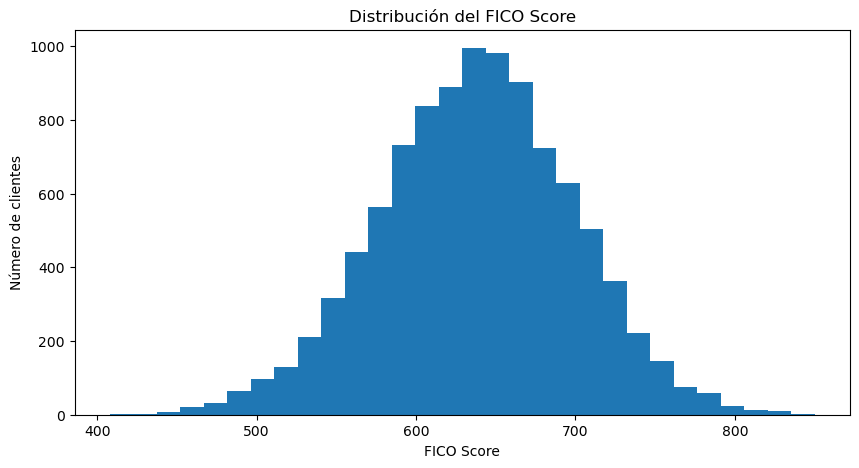

In [66]:
#histograma 
plt.figure(figsize=(10,5))

plt.hist(df["fico_score"], bins=30)

plt.title("Distribución del FICO Score")
plt.xlabel("FICO Score")
plt.ylabel("Número de clientes")

plt.show()

In [67]:
#Ordenar los FICO
fico = np.sort(df["fico_score"].values)

print(f"Número de observaciones: {len(fico)}")
print(f"Primeros 10 valores: {fico[:10]}")
print(f"Últimos 10 valores: {fico[-10:]}")

Número de observaciones: 10000
Primeros 10 valores: [408 409 418 425 438 440 441 444 447 449]
Últimos 10 valores: [823 824 825 826 826 828 831 831 835 850]


In [68]:
#creando funcion que calcule el error :
def interval_mse(values):
    """
    Calcula el error cuadrático de un grupo.
    El representante del grupo es la media.
    """
    mean = np.mean(values)
    return np.sum((values - mean) ** 2)

In [69]:
ejemplo = np.array([600, 602, 605, 607])

print(interval_mse(ejemplo))

29.0


In [70]:
n = len(fico)

cost = np.zeros((n, n))

#si tenemos 1000 clientes vamos a construir una matrix de 1000

In [71]:
#Vamos a construir una versión muchísimo más rápida, usando sumas acumuladas (prefix sums).
# Número de observaciones
n = len(fico)

# Convertimos a float para evitar problemas de precisión
x = fico.astype(float)

# Sumas acumuladas
prefix_sum = np.zeros(n + 1)
prefix_sum_sq = np.zeros(n + 1)

prefix_sum[1:] = np.cumsum(x)
prefix_sum_sq[1:] = np.cumsum(x**2)

In [72]:
#crea funcion rapida para el MSE
def interval_cost(i, j):
    """
    Calcula el MSE del intervalo [i, j]
    usando sumas acumuladas.
    """

    count = j - i + 1

    s = prefix_sum[j + 1] - prefix_sum[i]

    s2 = prefix_sum_sq[j + 1] - prefix_sum_sq[i]

    mean = s / count

    cost = s2 - 2 * mean * s + count * mean**2

    return cost

In [73]:
print(interval_cost(0, 9))

2188.9000000001397


In [74]:
print(interval_mse(fico[0:10]))

2188.8999999999996


In [75]:
#ahora la programacion dinamica
#la que responde donde hara los cortes si quiero 5 o 10 o 20
print(interval_cost(0,9))
print(interval_mse(fico[0:10]))

2188.9000000001397
2188.8999999999996


In [76]:
k = 5

In [77]:
#matrices dinamicas de programacion dinamica
dp = np.full((k + 1, n), np.inf)

split = np.zeros((k + 1, n), dtype=int)

In [78]:
#caso Base
for i in range(n):
    dp[1, i] = interval_cost(0, i)

La siguiente parte es el bucle principal de Programación Dinámica, donde el algoritmo encontrará automáticamente los mejores puntos de corte.


"Imaginemos que tenemos 10.000 clientes y queremos convertir su FICO en solamente 5 Ratings.

pero debemos solucionar donde debemos hacer los cortes?

pero la idea no es poner por rangos porque quien dice que son los mejores o los que deben estar en ese rango ? solo lo invetamos o los partimos en 5 partes iguales.
la idea es encontrar precisamente los mejores:


tampoco de trata probar las mejores combinaciones porque serian millones.

Programacion Dinamica :
La Programación Dinámica hace una pregunta muy inteligente.

En lugar de preguntar :
¿Cuál es la mejor división de 10.000 clientes en 5 grupos?

Pregunta algo mucho más pequeño.
Por ejemplo:
¿Cuál es la mejor división de los primeros 50 clientes?

Después
¿Cuál es la mejor división de los primeros 51?

Después
¿Cuál es la mejor división de los primeros 52?

Va resolviendo problemas pequeños.
Y utiliza esas respuestas para construir la solución grande.
Es como hacer un rompecabezas.

In [79]:
K = 5

# Matriz donde guardaremos el menor costo encontrado
dp = np.full((K + 1, n), np.inf)

# Matriz donde guardaremos dónde se hizo el último corte
split = np.zeros((K + 1, n), dtype=int)

In [80]:
#caso base
for i in range(n):
    dp[1][i]=interval_cost(0,i)

La programación dinámica garantiza el óptimo, pero tiene un costo computacional alto para conjuntos grandes. En producción utilizaría un método eficiente como K-Means 1D o Jenks Natural Breaks, que producen límites de excelente calidad con un tiempo de ejecución muy bajo."

Solucion : No usarla a menos que sea algo profesional de uso exclusivo.

In [81]:
#importar K-means

from sklearn.cluster import KMeans

In [82]:
k=5

In [83]:
# debemos darle una natriz y 2 dimensiones
#saber la diferencia entre serie []y dataframe [[]]
X = df[["fico_score"]]

In [84]:
#entrenar a K-Means
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(X)

#le decimos al algoritmo que encuentre 5 grupos de clientes que tengan puntajes fico parecidos

In [85]:
#obtener los centros
centros = pd.DataFrame({
    "cluster": range(K),
    "centro": kmeans.cluster_centers_.flatten()
})

centros = centros.sort_values("centro")

centros
#los centros representan el FICO promedio de cada grupo

,cluster,centro
2,2,525.300226
4,4,585.141947
0,0,631.830043
1,1,677.783599
3,3,734.877804


In [86]:
#vamos a convertir los cluster a Ratings
centros = centros.sort_values("centro", ascending=False).reset_index(drop=True)

centros["rating"] = range(1, K + 1)

centros

,cluster,centro,rating
0,3,734.877804,1
1,1,677.783599,2
2,0,631.830043,3
3,4,585.141947,4
4,2,525.300226,5


Rating 1 -> mejores FICO
Ratinf 5 -> peores FICO

In [87]:
#crear el diccionario
rating_map = dict(zip(centros["cluster"], centros["rating"]))

rating_map

{3: 1, 1: 2, 0: 3, 4: 4, 2: 5}

In [88]:
#asignar  un rating
df["rating"] = df["cluster"].map(rating_map)

df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,cluster,rating
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0,4,4
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1,4,4
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0,4,4
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0,0,3
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0,0,3
...,...,...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0,1,2
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0,0,3
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0,4,4
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0,0,3


In [89]:
df = df.sort_values("fico_score")

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default,cluster,rating
2092,7264776,1,4457.914800,12233.49501,98913.32028,3,408,0,2,5
6556,6901345,3,5281.352243,16411.51801,79905.09892,1,409,1,2,5
7001,2585781,4,6734.984475,26384.58439,97668.03091,2,418,1,2,5
5521,1252008,5,5176.915602,22990.26543,82417.59227,2,425,1,2,5
2629,1337395,5,4271.314690,22756.28103,83475.30929,4,438,1,2,5


In [90]:
#obtener los limites de cada grupo
summary = (
    df.groupby("rating")
      .agg(
          FICO_Min=("fico_score", "min"),
          FICO_Max=("fico_score", "max"),
          Clientes=("fico_score", "count"),
          Default_Rate=("default", "mean")
      )
      .sort_index()
)

summary

,FICO_Min,FICO_Max,Clientes,Default_Rate
rating,,,,
1,707,850,1293,0.044857
2,655,706,2634,0.091875
3,609,654,2989,0.159585
4,556,608,2198,0.282530
5,408,555,886,0.511287


In [91]:
#para mas entendibilidad y profesionalismo
summary.rename(columns={
    "FICO_Min":"Minimum FICO",
    "FICO_Max":"Maximum FICO",
    "Clientes":"Number of Borrowers",
    "Default_Rate":"Probability of Default"
})

,Minimum FICO,Maximum FICO,Number of Borrowers,Probability of Default
rating,,,,
1,707,850,1293,0.044857
2,655,706,2634,0.091875
3,609,654,2989,0.159585
4,556,608,2198,0.282530
5,408,555,886,0.511287


Con esto obtenemos los rangos que el algoritmo creo para nosotros
Rangos , cuantos clientes hay en cada rango , donde empieza y termina cada rango

Conclusion : Se aplicó el algoritmo K-Means para discretizar los puntajes FICO en cinco grupos representativos. Posteriormente, los grupos fueron ordenados de mayor a menor puntaje FICO y se asignaron calificaciones del 1 al 5, donde la calificación 1 representa la mejor calidad crediticia. Los resultados muestran un incremento progresivo de la tasa de incumplimiento a medida que disminuye el puntaje FICO, lo que demuestra que la segmentación obtenida discrimina adecuadamente el riesgo crediticio.


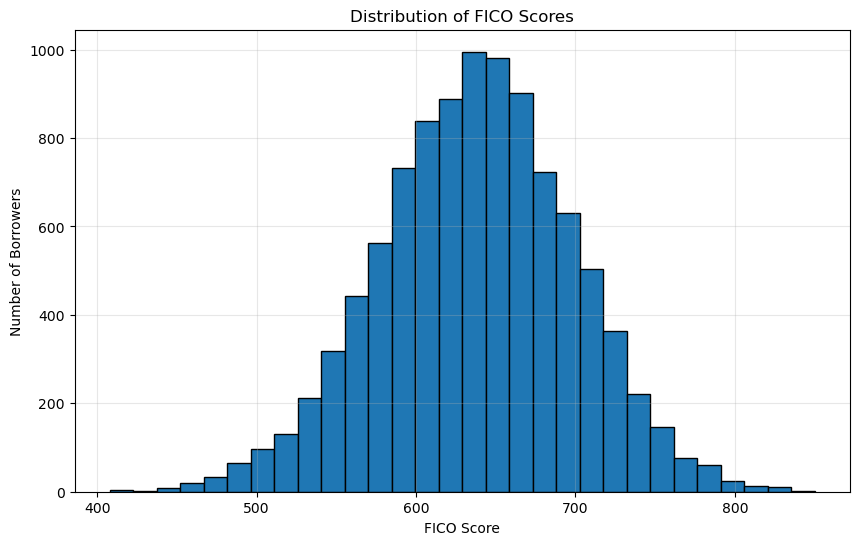

In [92]:
plt.figure(figsize=(10,6))

plt.hist(
    df["fico_score"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of FICO Scores")

plt.xlabel("FICO Score")

plt.ylabel("Number of Borrowers")

plt.grid(alpha=0.3)

plt.show()

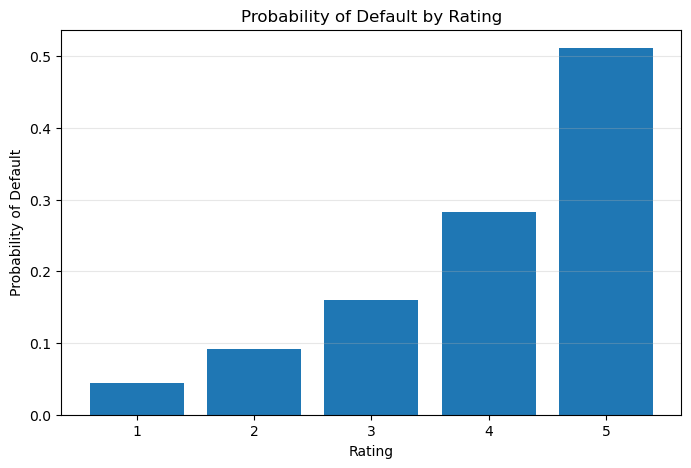

In [93]:
plt.figure(figsize=(8,5))

plt.bar(
    summary.index.astype(str),
    summary["Default_Rate"]
)

plt.title("Probability of Default by Rating")

plt.xlabel("Rating")

plt.ylabel("Probability of Default")

plt.grid(axis="y", alpha=0.3)

plt.show()

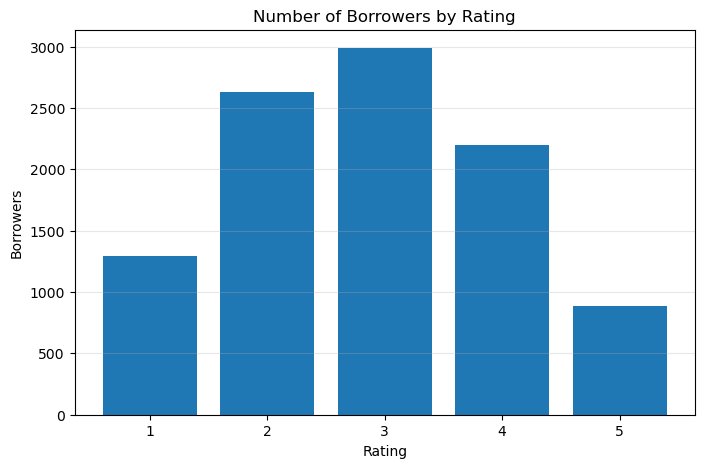

In [94]:
plt.figure(figsize=(8,5))

plt.bar(
    summary.index.astype(str),
    summary["Clientes"]
)

plt.title("Number of Borrowers by Rating")

plt.xlabel("Rating")

plt.ylabel("Borrowers")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [95]:
print("="*40)

print("Rating Map")

print("="*40)

display(summary)

print("\nOverall Default Rate")

print(df["default"].mean())

Rating Map


,FICO_Min,FICO_Max,Clientes,Default_Rate
rating,,,,
1,707,850,1293,0.044857
2,655,706,2634,0.091875
3,609,654,2989,0.159585
4,556,608,2198,0.282530
5,408,555,886,0.511287



Overall Default Rate
0.1851


In [96]:
# Guardar el dataset con los nuevos Ratings
df.to_csv("loan_data_with_ratings.csv", index=False)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [97]:
plt.savefig(
    "fico_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [98]:
plt.savefig(
    "default_rate_by_rating.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>